# 降维算法


## PCA主成分分析

找到一个新的坐标，使高维映射到低维的分布最分散
PCA降维缺点：离群点的影响较大。

In [29]:
# -*- coding: utf-8 -*-

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


def loadDataSet(filename):
    df = pd.read_table(filename, sep='\t')
    return np.array(df)

def showData(dataMat, reconMat):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(dataMat[:, 0], dataMat[:, 1], c='green')
    ax.scatter(np.array(reconMat[:, 0]), reconMat[:, 1], c='red')
    plt.show()

dataMat = np.random.randn(100, 300)

### web_search algrithm

网上搜到的

In [30]:

def web_pca(dataMat, topNfeat=999999):

    # 1.对所有样本进行中心化（所有样本属性减去属性的平均值）
    meanVals = np.mean(dataMat, axis=0)
    meanRemoved = dataMat - meanVals

    # 2.计算样本的协方差矩阵 XXT
    covmat = np.cov(meanRemoved, rowvar=0)

    # 3.对协方差矩阵做特征值分解，求得其特征值和特征向量，并将特征值从大到小排序，筛选出前topNfeat个
    eigVals, eigVects = np.linalg.eig(np.mat(covmat))
    eigValInd = np.argsort(eigVals)
    eigValInd = eigValInd[:-(topNfeat+1):-1]    # 取前topNfeat大的特征值的索引
    redEigVects = eigVects[:, eigValInd]        # 取前topNfeat大的特征值所对应的特征向量

    # 4.将数据转换到新的低维空间中
    lowDDataMat = meanRemoved * redEigVects     # 降维之后的数据
    reconMat = (lowDDataMat * redEigVects.T) + meanVals # 重构数据，可在原数据维度下进行对比查看
    return np.array(lowDDataMat), np.array(reconMat)

d:\Application\Anaconda\envs\qwen\lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Application\Anaconda\envs\qwen\lib\site-packages\matplotlib\collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


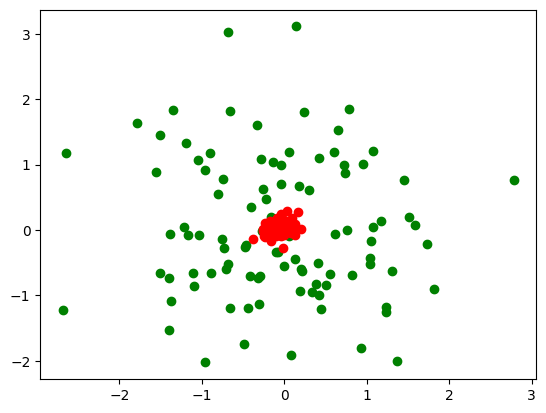

(100, 2)


In [31]:
lowDDataMat, reconMat = web_pca(dataMat, 2)
#showData(dataMat, lowDDataMat)
showData(dataMat, reconMat)
print(lowDDataMat.shape)

### sklearn PCA

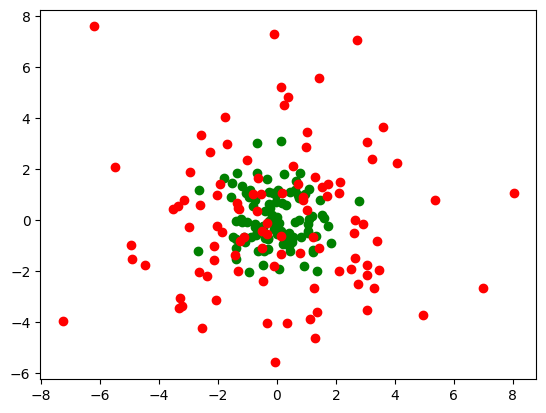

In [36]:
from sklearn.decomposition import PCA

# 创建一个示例数据集
skdata = dataMat

# 实例化PCA对象，设置降维后的维度为2
skpca = PCA(n_components=2)

# 拟合数据
skpca.fit(skdata)

# 进行降维
skreduced = skpca.transform(skdata)
showData(skdata, skreduced)

### chatGPT pca

In [33]:


def chatPCA(X, k):
    """
    实现PCA算法
    :param X: 输入数据矩阵，每一行表示一个样本，每一列表示一个特征
    :param k: 降维后的维度
    :return: 降维后的数据矩阵
    """
    # Step 1: 中心化数据
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean
    
    # Step 2: 计算协方差矩阵
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # Step 3: 计算特征值和特征向量
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Step 4: 选择前k个特征向量构成投影矩阵
    idx = eigenvalues.argsort()[::-1]  # 对特征值从大到小排序，并返回索引
    topk_eigenvectors = eigenvectors[:, idx[:k]]
    
    # Step 5: 将数据投影到新的低维空间中
    X_reduced = np.dot(X_centered, topk_eigenvectors)
    
    return X_reduced


d:\Application\Anaconda\envs\qwen\lib\site-packages\matplotlib\cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Application\Anaconda\envs\qwen\lib\site-packages\matplotlib\collections.py:194: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


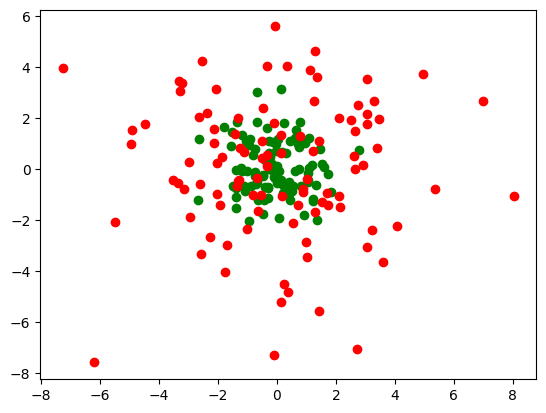

In [34]:

# 示例数据集
chatdata = dataMat

# 调用PCA函数进行降维，设置降维后的维度为2
k = 2
chat_reduced = chatPCA(chatdata, k)

showData(chatdata, chat_reduced)

## LDA

Linear Discriminant Analysis

## LLE 

局部线性嵌入

## Laplacian Eigenmaps 

拉普拉斯特征映射